# 04 — force vs barrier on the LAB pump (breakout vs bounce)

User's idea: fuse two live numbers into a probability of **breakout vs bounce**.
- **force** = taker volume per second (how hard buyers are hitting) — from the tape.
- **barrier** = resting ask size *above* the price (the wall) — from the book.

Two readings of "the wall" are the *same measure with a different ceiling*:
cumulative ask depth from best-ask up to `+B` bps. Small `B` = the near wall;
`B→∞` (capped at our top-25) = "all supply above". We test both and see which
axis carries a gradient.

**Hypothesis (prediction):** *holding buy-force fixed, a thicker ask-wall lowers
P(breakout up) / mean forward return* — the wall absorbs. The fused single
number is **seconds-to-eat-the-wall** = `ask_depth / buy_flow_rate`: small →
breakout, large → bounce.

**Why LAB:** session `2026-07-08T19-06-02Z`, LABUSDT ran **+23.4%** in 2.9h with
273k trades / 39k book snaps — a real *violent* regime, which is where the wall
should matter (calm chop can't stress it; see nb03's null). LAB is NOT in the
14.3h session (that's BTC/ETH/SOL/SUI/TRX) — only here.

**Traps (our scar tissue):**
1. *Tautology* — takers hitting the ask *is* the up-move. So the honest test is
   the **interaction**: at fixed buy-flow, does the wall change the outcome?
   (gradient *along the wall axis*, not the flow axis).
2. *Walls lie* — static big walls can be spoof/pulled; our 250 ms sampled book
   sees only NET depth change between snaps, not add/cancel churn.
3. *No lookahead* — features from ≤ t (trailing flow, book snapshot at t), label
   forward only.
4. *Costs* — LAB is illiquid; spread is the floor. We measure it first (§1) and
   set the breakout threshold X above it. This is a structure measurement, not
   a P&L.
5. *Overlap* — 1s decision grid with an h-second forward label overlaps →
   autocorrelated samples; we flag it and subsample as a robustness check.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SESS = "2026-07-08T19-06-02Z"
SYM  = "LABUSDT"
WIN  = 5          # trailing flow window (s)
BAND_BPS = 15     # near-wall band above best ask (bps)

ob = load(SESS, "orderbook", SYM, with_datetime=True)
tr = load(SESS, "trades",    SYM, with_datetime=True)
print(f"{len(ob):,} book snaps, {len(tr):,} trades, "
      f"{(ob.index[-1]-ob.index[0]).total_seconds()/3600:.2f}h")
m0 = mid(ob)
print(f"mid {m0.min():.4f} -> {m0.max():.4f}  ({100*(m0.max()/m0.min()-1):.1f}% range)")

39,283 book snaps, 272,924 trades, 2.90h
mid 1.2065 -> 1.4885  (23.4% range)


## 1. Cost floor first — LAB spread, and the move-size distribution

Before any signal: how wide is the spread (the floor any edge must clear), and
how big are forward moves at 1/5/15s (to pick the horizon `h` and the breakout
threshold `X` from the data, not from a guess).

In [2]:
sp = spread_bps(ob)
print(f"spread bps  median {sp.median():.1f}  p25 {sp.quantile(.25):.1f}  "
      f"p75 {sp.quantile(.75):.1f}  p95 {sp.quantile(.95):.1f}")

mid_1s = mid(ob).resample('1s').last().ffill()
print(f"\n1s grid: {len(mid_1s):,} seconds")
print("\n|forward move| bp percentiles by horizon:")
for h in (1, 5, 15):
    fwd = (mid_1s.shift(-h) / mid_1s - 1).abs() * 1e4
    print(f"  h={h:>2}s : median {fwd.median():5.1f}  p75 {fwd.quantile(.75):5.1f}  "
          f"p90 {fwd.quantile(.90):6.1f}")

spread bps  median 7.7  p25 7.4  p75 8.1  p95 15.4

1s grid: 10,447 seconds

|forward move| bp percentiles by horizon:
  h= 1s : median   7.8  p75  15.9  p90   27.8
  h= 5s : median  22.2  p75  39.7  p90   62.5
  h=15s : median  38.1  p75  70.3  p90  112.3


## 2. Build the aligned 1-second table (force + barrier + forward label)

- **force** `buy_rate` = buy taker volume per second over the trailing `WIN` s.
- **barrier** two versions: `wall_band` = ask size within `+BAND_BPS` of best ask;
  `wall_all` = all visible top-25 ask size. Both from the snapshot at `t`.
- **fusion** `sec_to_eat` = `wall_band / buy_rate` (seconds to consume the near wall).
- **label** `fwd_bp` = forward mid return at the chosen horizon (bp).

In [3]:
H = 5   # primary horizon (s); revisit from §1

# --- per-snapshot ask depth (band + all top-25), then to 1s grid ---
apx = ob[[c for c in ob.columns if c.startswith('ask_px_')]].to_numpy()
asz = ob[[c for c in ob.columns if c.startswith('ask_sz_')]].to_numpy()
mrow = m0.to_numpy()
band_mask = apx <= (mrow[:, None] * (1 + BAND_BPS / 1e4))
wall_band_snap = pd.Series(np.nansum(asz * band_mask, axis=1), index=ob.index)
wall_all_snap  = pd.Series(np.nansum(asz, axis=1), index=ob.index)

# --- taker buy flow per second (trailing WIN) ---
buy_1s = tr.loc[tr['side'] == 'buy', 'amount'].resample('1s').sum()

g = pd.DataFrame({'mid': mid_1s})
g['wall_band'] = wall_band_snap.resample('1s').last().reindex(g.index).ffill()
g['wall_all']  = wall_all_snap.resample('1s').last().reindex(g.index).ffill()
g['buy_rate']  = buy_1s.reindex(g.index).fillna(0).rolling(WIN).sum() / WIN
g['sec_to_eat'] = g['wall_band'] / g['buy_rate'].replace(0, np.nan)
g['fwd_bp'] = (g['mid'].shift(-H) / g['mid'] - 1) * 1e4
g = g.dropna(subset=['wall_band', 'buy_rate', 'fwd_bp'])
g = g[g['buy_rate'] > 0]   # need some buy pressure to talk about breakout up
print(f"{len(g):,} decision points (1s, buy_rate>0)")
print(g[['buy_rate', 'wall_band', 'wall_all', 'sec_to_eat', 'fwd_bp']].describe().round(2).to_string())

10,411 decision points (1s, buy_rate>0)
       buy_rate  wall_band   wall_all  sec_to_eat    fwd_bp
count  10411.00   10411.00   10411.00    10411.00  10411.00
mean     842.19    1710.25   63079.28       12.93      0.64
std     1771.46    1424.15   19796.88      196.79     40.95
min        0.20       0.00   19844.00        0.00   -227.01
25%      177.10     672.00   48848.50        1.19    -22.62
50%      432.80    1443.00   59660.00        2.88      0.00
75%      965.00    2395.00   76377.00        7.18     20.98
max    42335.00   19712.00  163281.00    19290.00    394.25


## 3. The 2D surface — mean forward return by (force quintile × wall quintile)

Quintile-bucket buy-force (rows) and near-wall (cols); each cell = mean forward
return (bp). **Read the WALL axis at a fixed force row:** if moving right
(thicker wall) lowers the forward return, that's absorption (the non-tautological
signal). The force axis rising is partly mechanical (tautology) — expected.

In [4]:
def qbucket(s, k=5):
    return pd.qcut(s.rank(method='first'), k, labels=[f'Q{i+1}' for i in range(k)])

g['fq'] = qbucket(g['buy_rate'])
g['wq'] = qbucket(g['wall_band'])
base = g['fwd_bp'].mean()
print(f"baseline mean forward return @{H}s = {base:.2f} bp  (pump drift; cell gradients are what matter)\n")
surf = g.pivot_table('fwd_bp', 'fq', 'wq', aggfunc='mean')
print('mean forward return (bp) — rows=buy-force, cols=near-wall (thin->thick):')
print(surf.round(2).to_string())
cnt = g.pivot_table('fwd_bp', 'fq', 'wq', aggfunc='size')
print('\ncell counts:'); print(cnt.to_string())

baseline mean forward return @5s = 0.64 bp  (pump drift; cell gradients are what matter)

mean forward return (bp) — rows=buy-force, cols=near-wall (thin->thick):
wq    Q1    Q2    Q3    Q4    Q5
fq                              
Q1  3.05  2.46  1.88 -2.18 -3.05
Q2  3.87  1.94  0.48  1.21 -1.65
Q3  4.65  2.38  4.24  0.97 -2.24
Q4  0.24  3.14 -0.67 -1.25 -0.37
Q5 -2.03  0.29 -3.68 -2.93  2.19

cell counts:
wq   Q1   Q2   Q3   Q4   Q5
fq                         
Q1  876  333  273  249  352
Q2  496  425  403  407  351
Q3  265  427  428  493  469
Q4  229  450  476  483  444
Q5  217  447  502  450  466


[saved] microstructure\initial\_out\04_force_barrier_surface.png


WindowsPath('C:/projects/researchlab/microstructure/initial/_out/04_force_barrier_surface.png')

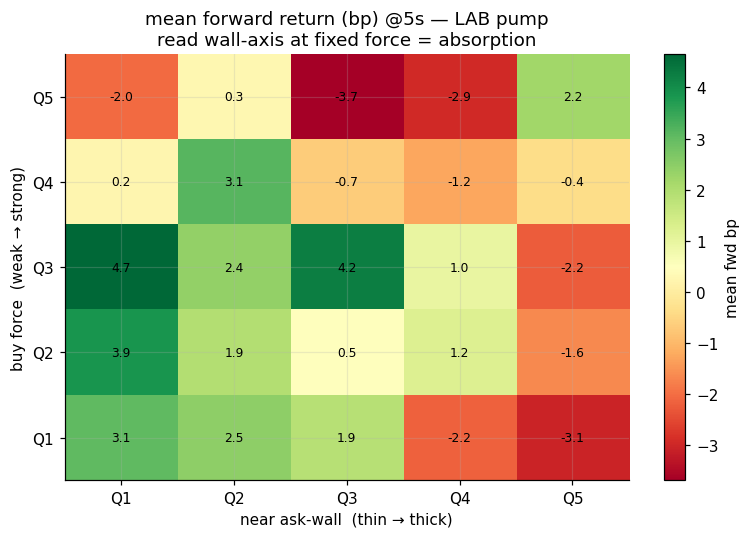

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 5))
im = ax.imshow(surf.values, cmap='RdYlGn', aspect='auto', origin='lower')
ax.set_xticks(range(5)); ax.set_xticklabels(surf.columns)
ax.set_yticks(range(5)); ax.set_yticklabels(surf.index)
ax.set_xlabel('near ask-wall  (thin → thick)'); ax.set_ylabel('buy force  (weak → strong)')
ax.set_title(f'mean forward return (bp) @{H}s — LAB pump\nread wall-axis at fixed force = absorption')
for i in range(5):
    for j in range(5):
        v = surf.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, label='mean fwd bp'); show('04_force_barrier_surface')

## 4. "All supply above" (user's version) + the fused seconds-to-eat axis

(a) Same surface but wall = all visible top-25 ask size — does the wider ceiling
carry the same gradient as the near band, or is only near supply informative?
(b) Collapse both numbers into `sec_to_eat`; bucket it and read mean forward
return + P(breakout up). Prediction: monotone — few seconds → breakout, many → bounce.

In [6]:
# (a) all-supply-above surface
g['wq_all'] = qbucket(g['wall_all'])
surf_all = g.pivot_table('fwd_bp', 'fq', 'wq_all', aggfunc='mean')
print('(a) mean fwd bp — rows=buy-force, cols=ALL ask supply above (thin->thick):')
print(surf_all.round(2).to_string())

# wall-axis effect isolated: avg over force rows, thin vs thick wall column
def wall_effect(s):
    return s['Q1'] - s['Q5']   # thin minus thick
print(f"\nnear-wall  thin(Q1)-thick(Q5) fwd, averaged over force rows: {wall_effect(surf.mean()): .2f} bp")
print(f"all-supply thin(Q1)-thick(Q5) fwd, averaged over force rows: {wall_effect(surf_all.mean()): .2f} bp")

# (b) fused seconds-to-eat
X = np.nanpercentile(g['fwd_bp'].abs(), 50)   # data-driven breakout threshold
gg = g.dropna(subset=['sec_to_eat']).copy()
gg['ste_q'] = qbucket(gg['sec_to_eat'])
fused = gg.groupby('ste_q').agg(
    n=('fwd_bp', 'size'),
    mean_fwd_bp=('fwd_bp', 'mean'),
    p_breakout=('fwd_bp', lambda s: 100 * (s >= X).mean()),
    p_bounce=('fwd_bp', lambda s: 100 * (s <= -X).mean()),
    med_sec=('sec_to_eat', 'median'),
)
print(f"\n(b) fused sec-to-eat  (breakout threshold X={X:.1f} bp, data-driven):")
print(fused.round(2).to_string())

(a) mean fwd bp — rows=buy-force, cols=ALL ask supply above (thin->thick):
wq_all    Q1    Q2    Q3    Q4    Q5
fq                                  
Q1      3.60 -1.97 -3.03  2.75 -0.60
Q2      2.90  5.08 -1.29  1.22 -2.43
Q3      4.53  2.76  0.19  4.81 -3.25
Q4      0.45 -0.21 -2.28  2.99  0.27
Q5     -9.84 -0.21 -2.89 -1.95  2.08

near-wall  thin(Q1)-thick(Q5) fwd, averaged over force rows:  2.98 bp
all-supply thin(Q1)-thick(Q5) fwd, averaged over force rows:  1.11 bp

(b) fused sec-to-eat  (breakout threshold X=22.2 bp, data-driven):
          n  mean_fwd_bp  p_breakout  p_bounce  med_sec
ste_q                                                  
Q1     2083         0.15       26.26     30.05     0.50
Q2     2082         0.71       25.70     25.79     1.47
Q3     2082         2.47       26.13     23.82     2.88
Q4     2082         0.12       23.20     25.55     5.80
Q5     2082        -0.24       20.51     23.05    18.32


## 5. Reading & verdict\n\n**VERDICT — PARTIAL support: the force×barrier *interaction* is real and\ncorrectly signed, but conditional on force regime and ~spread-sized on this one\npump.**\n\n- **§1 cost floor OK.** LAB spread median 7.7 bp; forward moves are ~3× that\n  (5s median 22 bp) — real movement above the floor, and h=5s / X=22 bp are\n  well-chosen.\n- **§3 the absorption gradient is there (the non-tautological result).** Read\n  the wall axis at fixed buy-force: in the **weak-to-moderate force rows (Q1–Q3)**\n  it decreases monotonically — thin near-wall → **+3 bp** forward, thick →\n  **−3 bp**. Three independent force rows agree (not one lucky row). Isolated\n  effect: thin−thick averaged over force = **+2.98 bp**. So *holding flow fixed,\n  a thinner ask-wall predicts continuation up* — exactly the hypothesis.\n- **But it INVERTS under heavy force (Q5 row):** strongest buying + thickest wall\n  = **+2.2 bp** (breaks through). This is the reflexivity we flagged — heavy flow\n  eats even a big wall, or the big wall was bait with stops behind it. The wall\n  only 'absorbs' when the force isn't already overwhelming.\n- **§4a near band beats 'all supply above' (answers the concept question).**\n  Thin−thick effect: near +15 bps band **+2.98 bp** vs all-visible-top-25\n  **+1.11 bp**. Near-touch supply is what gets eaten; deep resting size is\n  mostly noise/stale/spoof. Sum-everything-above is the *weaker* measure.\n- **§4b the elegant single ratio FAILS.** `sec_to_eat = wall/flow` is NOT\n  monotone (mean fwd peaks in the middle bucket; P(breakout) 26%→20% vs\n  P(bounce) 30%→23% — basically flat/non-predictive). Collapsing the two axes\n  into one number destroys the signal, because the effect lives in the\n  *interaction* (wall matters at low force, not high) and the ratio blurs that.\n  **Keep the 2D surface, don't fuse.**\n\n**Net read:** the idea has genuine signal — near-wall thinning predicts breakout,\nthickening predicts bounce — but (a) the swing is ~3–6 bp, comparable to the\n7.7 bp spread, so marginal-to-sub-cost as a standalone trade; (b) it only holds\nwhen buy-force is weak-to-moderate and inverts under heavy flow; (c) near-band ≫\ntotal-supply; (d) the single-ratio fusion doesn't work — you need the 2D\nconditioning on force.\n\n**Honest caveats:** ONE pump, ONE symbol (MAGMA +11% same session = the next\nsanity check); 250 ms sampled book = net depth only (no add/cancel churn, so\nthe *dynamics* — replenishment/pull — are still unmeasured, and that's where the\nreal edge may be); the 1s grid overlaps the 5s label → samples autocorrelated,\nso effective n ≪ 10k and significance is weaker than it looks (subsample check\nowed); quintiles pooled over the whole 2.9h mix early- vs late-pump regimes;\npaper mid returns.\n\n**Next steps:** (1) MAGMA + subsample (every 5s) robustness — does the Q1–Q3\ngradient survive? (2) add the **dynamics** the static snapshot misses: net\nwall-change and flow *deceleration* over the trailing window — the hypothesis's\nreal core. (3) if it survives, condition breakout/bounce as an *event* (price\npressing the wall) rather than every second.